# Qwen3-0.6B Base Model Analysis on GovReport

**Goal**: Understand how the base (unfinetuned) Qwen3-0.6B performs on long-document summarization, and specifically **where** it fails.

**Inference**: Uses llama.cpp server (OpenAI-compatible API at `localhost:8100`) for fast inference with the Q4_K_M quantized model.

We test on actual GovReport samples at different lengths to identify:
1. Overall summary quality (ROUGE scores)
2. Positional bias: does the model ignore middle/end content? ("Lost in the Middle")
3. How quality degrades as document length increases
4. Common failure modes: repetition, hallucination, truncation, etc.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import json
import requests
import time
from datasets import load_dataset
from transformers import AutoTokenizer
from rouge_score import rouge_scorer

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# llama.cpp server config
LLAMA_BASE_URL = "http://localhost:8100/v1"

# Verify server is running
resp = requests.get(f"{LLAMA_BASE_URL}/models")
models = resp.json()
print(f"llama.cpp server: {models['data'][0]['id']}")
print(f"  Context train: {models['data'][0]['meta']['n_ctx_train']:,} tokens")
print(f"  Parameters: {models['data'][0]['meta']['n_params']:,}")
print(f"  GGUF size: {models['data'][0]['meta']['size'] / 1e6:.0f} MB")

llama.cpp server: Qwen3-0.6B-Q4_K_M.gguf
  Context train: 40,960 tokens
  Parameters: 596,049,920
  GGUF size: 391 MB


In [2]:
# Load tokenizer (for counting tokens — no model weights needed)
MODEL_NAME = "Qwen/Qwen3-0.6B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: vocab_size={tokenizer.vocab_size:,}")

Tokenizer loaded: vocab_size=151,643


In [3]:
# Load dataset
ds = load_dataset("ccdv/govreport-summarization")
test = ds["test"]
print(f"Test split: {len(test)} examples")

Test split: 973 examples


In [4]:
def strip_think_tags(text: str) -> str:
    """Strip Qwen3 thinking tags (closed or unclosed)."""
    text = re.sub(r"<think>.*?</think>\s*", "", text, flags=re.DOTALL)
    text = re.sub(r"<think>.*", "", text, flags=re.DOTALL)
    return text.strip()

def generate_summary(doc, max_doc_chars=None, max_new_tokens=512):
    """Generate summary via llama.cpp OpenAI-compatible API.
    
    Args:
        doc: Document text
        max_doc_chars: Truncate document to this many chars (approximate token control).
                       ~3.2 chars/token for English text, so 8000 chars ≈ 2500 tokens.
        max_new_tokens: Max tokens to generate
    
    Returns:
        (summary_text, approx_input_tokens, approx_output_tokens)
    """
    if max_doc_chars and len(doc) > max_doc_chars:
        doc = doc[:max_doc_chars]
    
    prompt = f"Summarize the following document:\n\n{doc}\n\nSummary:"
    input_tokens = len(tokenizer.encode(prompt, add_special_tokens=False))
    
    t0 = time.time()
    resp = requests.post(
        f"{LLAMA_BASE_URL}/chat/completions",
        json={
            "messages": [{"role": "user", "content": prompt}],
            "max_tokens": max_new_tokens,
            "temperature": 0.3,
            "top_p": 0.9,
        },
        timeout=300,
    )
    elapsed = time.time() - t0
    resp.raise_for_status()
    data = resp.json()
    
    msg = data["choices"][0]["message"]
    content = msg.get("content") or ""
    reasoning = msg.get("reasoning_content") or ""
    text = content if content.strip() else reasoning
    summary = strip_think_tags(text)
    
    usage = data.get("usage", {})
    out_tokens = usage.get("completion_tokens", len(tokenizer.encode(summary, add_special_tokens=False)))
    in_tokens = usage.get("prompt_tokens", input_tokens)
    
    return summary, in_tokens, out_tokens, elapsed

# Quick test
print("Testing API call...")
test_sum, test_in, test_out, test_time = generate_summary("The cat sat on the mat.", max_new_tokens=50)
print(f"  Response: '{test_sum[:100]}'")
print(f"  Tokens: {test_in} in, {test_out} out, {test_time:.1f}s")

Testing API call...


  Response: 'Okay, let's see. The user wants a summary of the document: "The cat sat on the mat." They also provi'
  Tokens: 24 in, 50 out, 21.9s


---
## 1. Quick test: does the model summarize at all?

In [5]:
# Test with a short doc first
ex = test[0]
doc_toks = len(tokenizer.encode(ex["report"], add_special_tokens=False))
print(f"Test doc: {doc_toks:,} tokens ({len(ex['report']):,} chars)")
print(f"Reference summary: {len(tokenizer.encode(ex['summary'], add_special_tokens=False)):,} tokens")
print()

# Use first ~6K chars ≈ 2K tokens for quick test
summary, in_len, out_len, elapsed = generate_summary(ex["report"], max_doc_chars=6400, max_new_tokens=300)
print(f"Input: {in_len} tokens | Output: {out_len} tokens | Time: {elapsed:.1f}s")
print(f"\n--- Generated Summary ---")
print(summary[:1000])
print(f"\n--- Reference Summary (first 500 chars) ---")
print(ex["summary"][:500])

Test doc: 11,653 tokens (64,660 chars)
Reference summary: 625 tokens



Input: 1171 tokens | Output: 300 tokens | Time: 2.2s

--- Generated Summary ---
The document outlines the process of technological innovation leading to commercialization, divided into three stages: inventing, transitioning to making, and selling. It emphasizes the role of the FDA and USDA in food safety: USDA oversees meat, poultry, and catfish, while FDA ensures food safety for all except regulated products. Key points include risk-based inspections, GRAS exemptions for substances like spices and food additives, labeling

--- Reference Summary (first 500 chars) ---
Multiple firms have produced cell-cultured meat as part of their research and development. These products appear likely to become available to consumers in coming years. FDA and USDA are the primary agencies responsible for overseeing the safety of the nation's food supply. However, some stakeholders have expressed concern about the agencies' oversight of cell-cultured meat amidst a fragmented federal food safety oversight

---
## 2. Evaluate across different document lengths

Select samples at different length buckets and measure ROUGE.

In [6]:
# Categorize test docs by length (in tokens)
test_doc_tokens = np.array([len(tokenizer.encode(ex["report"], add_special_tokens=False)) for ex in test])
test_sum_tokens = np.array([len(tokenizer.encode(ex["summary"], add_special_tokens=False)) for ex in test])
test_doc_chars = np.array([len(ex["report"]) for ex in test])

# Define length buckets (in tokens)
buckets = [
    ("short (<2K)",    0,    2000),
    ("medium (2-4K)",  2000, 4000),
    ("long (4-8K)",    4000, 8000),
    ("very long (8-16K)", 8000, 16000),
    ("extreme (>16K)", 16000, 999999),
]

print(f"{'Bucket':<22} | {'Count':>6} | {'Med doc toks':>13} | {'Med sum toks':>13} | {'Med doc chars':>14}")
print("-" * 80)
for label, lo, hi in buckets:
    mask = (test_doc_tokens >= lo) & (test_doc_tokens < hi)
    n = mask.sum()
    if n > 0:
        print(f"{label:<22} | {n:>6} | {np.median(test_doc_tokens[mask]):>13,.0f} | {np.median(test_sum_tokens[mask]):>13,.0f} | {np.median(test_doc_chars[mask]):>14,.0f}")

Bucket                 |  Count |  Med doc toks |  Med sum toks |  Med doc chars
--------------------------------------------------------------------------------
short (<2K)            |     13 |         1,568 |           320 |          7,541
medium (2-4K)          |    115 |         3,279 |           705 |         17,377
long (4-8K)            |    333 |         6,205 |           722 |         31,366
very long (8-16K)      |    399 |        10,895 |           743 |         56,582
extreme (>16K)         |    113 |        19,280 |           778 |         98,062


In [7]:
# Run evaluation: pick samples from each bucket
# Use llama.cpp API — much faster than loading model in Python

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

np.random.seed(42)
SAMPLES_PER_BUCKET = 3

results = []

for label, lo, hi in buckets:
    mask = (test_doc_tokens >= lo) & (test_doc_tokens < hi)
    indices = np.where(mask)[0]
    if len(indices) == 0:
        continue
    
    sample_idx = np.random.choice(indices, size=min(SAMPLES_PER_BUCKET, len(indices)), replace=False)
    
    for idx in sample_idx:
        ex = test[int(idx)]
        doc_len = test_doc_tokens[idx]
        doc_chars = len(ex["report"])
        
        # For context control: cap at ~8K tokens ≈ 26K chars
        # If doc fits in 8K tokens, use full doc
        max_chars = min(doc_chars, 26000)
        max_new = min(int(test_sum_tokens[idx]) + 100, 1024)
        
        print(f"  [{label}] idx={idx}, doc={doc_len:,} toks ({doc_chars:,} chars), budget={max_chars:,} chars...", 
              end=" ", flush=True)
        
        try:
            summary, in_len, out_len, elapsed = generate_summary(
                ex["report"], max_doc_chars=max_chars, max_new_tokens=max_new
            )
            
            scores = scorer.score(ex["summary"], summary)
            
            results.append({
                "idx": int(idx),
                "bucket": label,
                "doc_tokens": int(doc_len),
                "input_tokens": in_len,
                "output_tokens": out_len,
                "elapsed": elapsed,
                "rouge1": scores["rouge1"].fmeasure,
                "rouge2": scores["rouge2"].fmeasure,
                "rougeL": scores["rougeL"].fmeasure,
                "generated": summary,
                "reference": ex["summary"],
                "doc_preview": ex["report"][:500],
            })
            
            print(f"R1={scores['rouge1'].fmeasure:.3f} R2={scores['rouge2'].fmeasure:.3f} RL={scores['rougeL'].fmeasure:.3f} ({elapsed:.1f}s)")
        
        except Exception as e:
            print(f"ERROR: {e}")

print(f"\nCompleted {len(results)} evaluations")

  [short (<2K)] idx=961, doc=1,521 toks (7,005 chars), budget=7,005 chars... 

R1=0.058 R2=0.000 RL=0.058 (2.0s)
  [short (<2K)] idx=797, doc=644 toks (2,650 chars), budget=2,650 chars... 

R1=0.314 R2=0.087 RL=0.248 (1.9s)
  [short (<2K)] idx=153, doc=1,656 toks (7,993 chars), budget=7,993 chars... 

R1=0.193 R2=0.067 RL=0.113 (2.8s)
  [medium (2-4K)] idx=380, doc=2,773 toks (14,762 chars), budget=14,762 chars... 

R1=0.298 R2=0.126 RL=0.194 (3.9s)
  [medium (2-4K)] idx=269, doc=2,611 toks (13,866 chars), budget=13,866 chars... 

...

R1=0.301 R2=0.102 RL=0.160 (5.7s)
  [very long (8-16K)] idx=562, doc=12,834 toks (67,874 chars), budget=26,000 chars... 

R1=0.252 R2=0.066 RL=0.129 (6.0s)
  [extreme (>16K)] idx=140, doc=31,837 toks (172,747 chars), budget=26,000 chars... 

R1=0.171 R2=0.039 RL=0.091 (5.5s)
  [extreme (>16K)] idx=547, doc=16,685 toks (86,103 chars), budget=26,000 chars... 

R1=0.221 R2=0.061 RL=0.127 (4.2s)
  [extreme (>16K)] idx=662, doc=19,095 toks (88,860 chars), budget=26,000 chars... 

R1=0.333 R2=0.105 RL=0.162 (6.7s)

Completed 15 evaluations


In [8]:
# Aggregate results by bucket
print(f"{'Bucket':<22} | {'N':>3} | {'ROUGE-1':>8} | {'ROUGE-2':>8} | {'ROUGE-L':>8} | {'Avg out toks':>13} | {'Avg time':>9}")
print("-" * 85)

bucket_scores = {}
for label, _, _ in buckets:
    bucket_results = [r for r in results if r["bucket"] == label]
    if not bucket_results:
        continue
    r1 = np.mean([r["rouge1"] for r in bucket_results])
    r2 = np.mean([r["rouge2"] for r in bucket_results])
    rl = np.mean([r["rougeL"] for r in bucket_results])
    avg_out = np.mean([r["output_tokens"] for r in bucket_results])
    avg_time = np.mean([r["elapsed"] for r in bucket_results])
    bucket_scores[label] = {"rouge1": r1, "rouge2": r2, "rougeL": rl, "n": len(bucket_results)}
    print(f"{label:<22} | {len(bucket_results):>3} | {r1:>8.3f} | {r2:>8.3f} | {rl:>8.3f} | {avg_out:>13.0f} | {avg_time:>8.1f}s")

# Overall
r1_all = np.mean([r["rouge1"] for r in results])
r2_all = np.mean([r["rouge2"] for r in results])
rl_all = np.mean([r["rougeL"] for r in results])
total_time = sum(r["elapsed"] for r in results)
print(f"{'OVERALL':<22} | {len(results):>3} | {r1_all:>8.3f} | {r2_all:>8.3f} | {rl_all:>8.3f} |               | {total_time:.0f}s total")

Bucket                 |   N |  ROUGE-1 |  ROUGE-2 |  ROUGE-L |  Avg out toks |  Avg time
-------------------------------------------------------------------------------------
short (<2K)            |   3 |    0.188 |    0.051 |    0.140 |           331 |      2.2s
medium (2-4K)          |   3 |    0.265 |    0.098 |    0.160 |           458 |      3.7s
long (4-8K)            |   3 |    0.347 |    0.124 |    0.178 |           582 |      5.6s
very long (8-16K)      |   3 |    0.268 |    0.087 |    0.142 |           545 |      5.5s
extreme (>16K)         |   3 |    0.242 |    0.068 |    0.127 |           572 |      5.5s
OVERALL                |  15 |    0.262 |    0.086 |    0.149 |               | 68s total


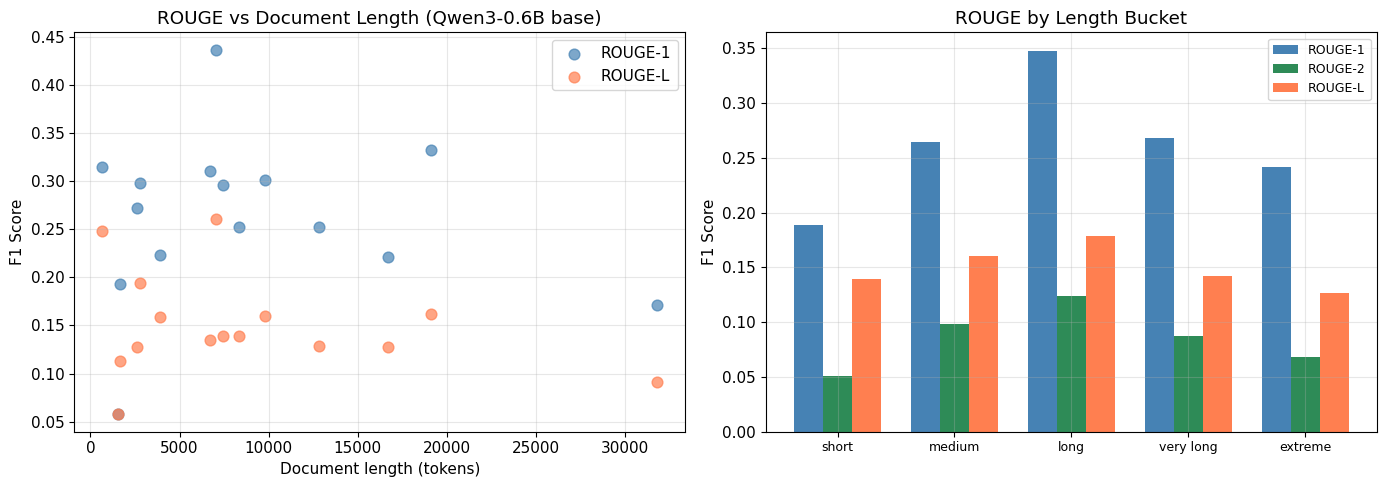

In [9]:
# Plot ROUGE vs document length
if len(results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    doc_lens = [r["doc_tokens"] for r in results]
    r1_scores = [r["rouge1"] for r in results]
    rl_scores = [r["rougeL"] for r in results]
    
    ax = axes[0]
    ax.scatter(doc_lens, r1_scores, s=60, alpha=0.7, color="steelblue", label="ROUGE-1")
    ax.scatter(doc_lens, rl_scores, s=60, alpha=0.7, color="coral", label="ROUGE-L")
    ax.set_xlabel("Document length (tokens)")
    ax.set_ylabel("F1 Score")
    ax.set_title("ROUGE vs Document Length (Qwen3-0.6B base)")
    ax.legend()
    
    # Bar chart by bucket
    ax = axes[1]
    bucket_names = list(bucket_scores.keys())
    x = np.arange(len(bucket_names))
    w = 0.25
    ax.bar(x - w, [bucket_scores[b]["rouge1"] for b in bucket_names], w, label="ROUGE-1", color="steelblue")
    ax.bar(x, [bucket_scores[b]["rouge2"] for b in bucket_names], w, label="ROUGE-2", color="seagreen")
    ax.bar(x + w, [bucket_scores[b]["rougeL"] for b in bucket_names], w, label="ROUGE-L", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels([b.split("(")[0].strip() for b in bucket_names], fontsize=9)
    ax.set_ylabel("F1 Score")
    ax.set_title("ROUGE by Length Bucket")
    ax.legend(fontsize=9)
    
    plt.tight_layout(); plt.show()

---
## 3. Positional analysis: "Lost in the Middle" test

For each generated summary, measure how much content it captures from the beginning, middle, and end of the document.

In [10]:
def ngram_overlap(source, target, n=3):
    """Fraction of target n-grams found in source."""
    words_s = source.lower().split()
    words_t = target.lower().split()
    if len(words_t) < n:
        return 0.0
    ngrams_s = set(tuple(words_s[i:i+n]) for i in range(len(words_s)-n+1))
    ngrams_t = [tuple(words_t[i:i+n]) for i in range(len(words_t)-n+1)]
    if not ngrams_t:
        return 0.0
    return sum(1 for ng in ngrams_t if ng in ngrams_s) / len(ngrams_t)

# For each result, measure where the generated summary draws content from
positional_data = []

for r in results:
    idx = r["idx"]
    doc = test[idx]["report"]
    gen_summary = r["generated"]
    ref_summary = r["reference"]
    
    words = doc.split()
    third = len(words) // 3
    
    parts = {
        "first": " ".join(words[:third]),
        "middle": " ".join(words[third:2*third]),
        "last": " ".join(words[2*third:]),
    }
    
    # Where does the GENERATED summary draw from?
    gen_overlap = {pos: ngram_overlap(part, gen_summary) for pos, part in parts.items()}
    # Where does the REFERENCE summary draw from? (for comparison)
    ref_overlap = {pos: ngram_overlap(part, ref_summary) for pos, part in parts.items()}
    
    positional_data.append({
        "idx": idx,
        "bucket": r["bucket"],
        "doc_tokens": r["doc_tokens"],
        "gen_first": gen_overlap["first"],
        "gen_middle": gen_overlap["middle"],
        "gen_last": gen_overlap["last"],
        "ref_first": ref_overlap["first"],
        "ref_middle": ref_overlap["middle"],
        "ref_last": ref_overlap["last"],
    })

# Summarize
gen_firsts = [d["gen_first"] for d in positional_data]
gen_middles = [d["gen_middle"] for d in positional_data]
gen_lasts = [d["gen_last"] for d in positional_data]
ref_firsts = [d["ref_first"] for d in positional_data]
ref_middles = [d["ref_middle"] for d in positional_data]
ref_lasts = [d["ref_last"] for d in positional_data]

print("Positional content overlap (3-gram):")
print(f"{'Position':<10} | {'Generated':>10} | {'Reference':>10} | {'Gap':>10}")
print("-" * 50)
for pos, gen, ref in [("First 1/3", gen_firsts, ref_firsts), 
                       ("Middle 1/3", gen_middles, ref_middles),
                       ("Last 1/3", gen_lasts, ref_lasts)]:
    g = np.mean(gen)
    r = np.mean(ref)
    print(f"{pos:<10} | {g:>10.3f} | {r:>10.3f} | {g-r:>+10.3f}")

# Normalized shares
gen_total = np.array(gen_firsts) + np.array(gen_middles) + np.array(gen_lasts)
ref_total = np.array(ref_firsts) + np.array(ref_middles) + np.array(ref_lasts)
safe_gen = gen_total > 0
safe_ref = ref_total > 0

print(f"\nNormalized share of content by position:")
if safe_gen.any():
    print(f"  Generated: first={np.array(gen_firsts)[safe_gen].sum()/gen_total[safe_gen].sum():.1%}  "
          f"middle={np.array(gen_middles)[safe_gen].sum()/gen_total[safe_gen].sum():.1%}  "
          f"last={np.array(gen_lasts)[safe_gen].sum()/gen_total[safe_gen].sum():.1%}")
if safe_ref.any():
    print(f"  Reference: first={np.array(ref_firsts)[safe_ref].sum()/ref_total[safe_ref].sum():.1%}  "
          f"middle={np.array(ref_middles)[safe_ref].sum()/ref_total[safe_ref].sum():.1%}  "
          f"last={np.array(ref_lasts)[safe_ref].sum()/ref_total[safe_ref].sum():.1%}")

Positional content overlap (3-gram):
Position   |  Generated |  Reference |        Gap
--------------------------------------------------
First 1/3  |      0.113 |      0.285 |     -0.172
Middle 1/3 |      0.037 |      0.164 |     -0.127
Last 1/3   |      0.045 |      0.120 |     -0.075

Normalized share of content by position:
  Generated: first=57.9%  middle=19.0%  last=23.1%
  Reference: first=50.0%  middle=28.9%  last=21.1%


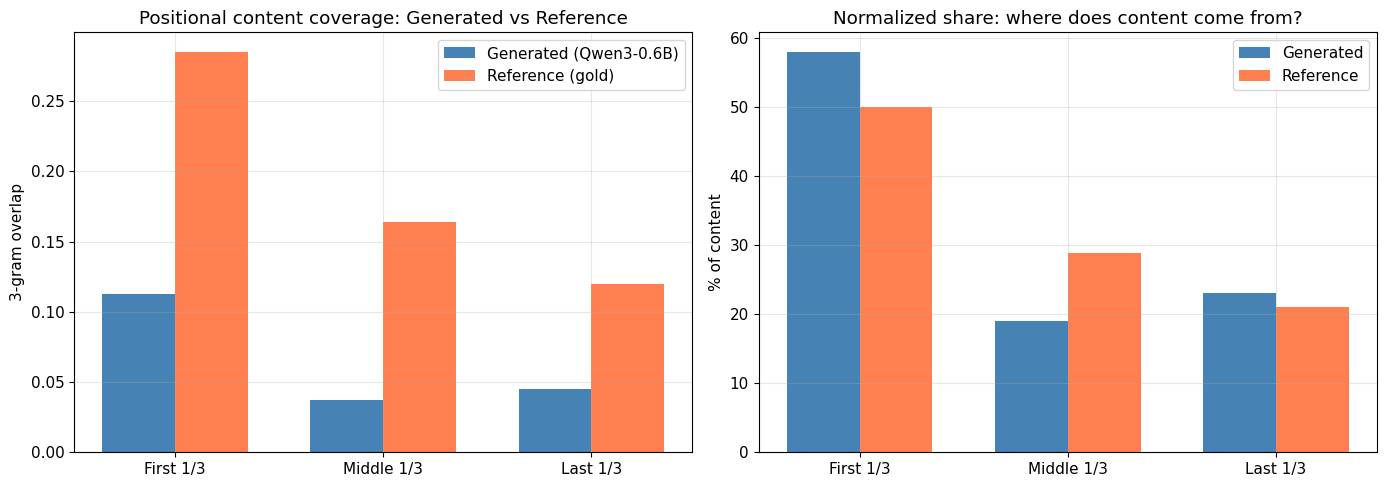

In [11]:
# Visualize positional bias
if len(positional_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart: generated vs reference positional overlap
    ax = axes[0]
    positions = ["First 1/3", "Middle 1/3", "Last 1/3"]
    gen_means = [np.mean(gen_firsts), np.mean(gen_middles), np.mean(gen_lasts)]
    ref_means = [np.mean(ref_firsts), np.mean(ref_middles), np.mean(ref_lasts)]
    x = np.arange(3)
    w = 0.35
    ax.bar(x - w/2, gen_means, w, label="Generated (Qwen3-0.6B)", color="steelblue")
    ax.bar(x + w/2, ref_means, w, label="Reference (gold)", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(positions)
    ax.set_ylabel("3-gram overlap")
    ax.set_title("Positional content coverage: Generated vs Reference")
    ax.legend()
    
    # Normalized share comparison
    ax = axes[1]
    if safe_gen.any() and safe_ref.any():
        gen_shares = [np.array(gen_firsts)[safe_gen].sum()/gen_total[safe_gen].sum()*100,
                      np.array(gen_middles)[safe_gen].sum()/gen_total[safe_gen].sum()*100,
                      np.array(gen_lasts)[safe_gen].sum()/gen_total[safe_gen].sum()*100]
        ref_shares = [np.array(ref_firsts)[safe_ref].sum()/ref_total[safe_ref].sum()*100,
                      np.array(ref_middles)[safe_ref].sum()/ref_total[safe_ref].sum()*100,
                      np.array(ref_lasts)[safe_ref].sum()/ref_total[safe_ref].sum()*100]
        ax.bar(x - w/2, gen_shares, w, label="Generated", color="steelblue")
        ax.bar(x + w/2, ref_shares, w, label="Reference", color="coral")
        ax.set_xticks(x)
        ax.set_xticklabels(positions)
        ax.set_ylabel("% of content")
        ax.set_title("Normalized share: where does content come from?")
        ax.legend()
    
    plt.tight_layout(); plt.show()

---
## 4. Failure mode analysis: read the actual outputs

Look at generated summaries side-by-side with references to identify patterns.

In [12]:
# Show all results side-by-side
for r in sorted(results, key=lambda x: x["doc_tokens"]):
    print(f"\n{'='*90}")
    print(f"  [{r['bucket']}] idx={r['idx']} | doc={r['doc_tokens']:,} toks | input={r['input_tokens']:,} | output={r['output_tokens']} toks")
    print(f"  ROUGE-1={r['rouge1']:.3f}  ROUGE-2={r['rouge2']:.3f}  ROUGE-L={r['rougeL']:.3f}")
    print(f"{'='*90}")
    
    print(f"\n  GENERATED ({len(r['generated'].split())} words):")
    print(f"  {r['generated'][:800]}")
    if len(r['generated']) > 800:
        print(f"  ...({len(r['generated'])-800} chars more)")
    
    print(f"\n  REFERENCE ({len(r['reference'].split())} words):")
    print(f"  {r['reference'][:800]}")
    if len(r['reference']) > 800:
        print(f"  ...({len(r['reference'])-800} chars more)")
    
    # Flag failure modes
    gen = r['generated']
    issues = []
    if len(gen.split()) < 20:
        issues.append("TOO SHORT")
    if len(gen.split()) > len(r['reference'].split()) * 3:
        issues.append("TOO LONG")
    
    # Check for repetition (repeated 4-grams)
    words = gen.lower().split()
    if len(words) >= 4:
        fourgrams = [tuple(words[i:i+4]) for i in range(len(words)-3)]
        unique_ratio = len(set(fourgrams)) / len(fourgrams) if fourgrams else 1
        if unique_ratio < 0.7:
            issues.append(f"REPETITIVE (unique 4-grams: {unique_ratio:.0%})")
    
    # Check if summary just copies beginning of doc
    doc_start = r['doc_preview'][:300].lower()
    gen_start = gen[:300].lower()
    if ngram_overlap(doc_start, gen_start, n=5) > 0.5:
        issues.append("COPIES DOC START")
    
    if issues:
        print(f"\n  ⚠ ISSUES: {', '.join(issues)}")


  [short (<2K)] idx=797 | doc=644 toks | input=661 | output=285 toks
  ROUGE-1=0.314  ROUGE-2=0.087  ROUGE-L=0.248

  GENERATED (44 words):
  The document outlines how staff integration and utilization in organizations, such as Congress, reflect their missions and priorities. In Congress, staff work in leadership, committees, and office settings, handling legislative, administrative, and representational tasks. CRS reports (e.g., *House of Representatives Staff Levels* from 1977-2016,

  REFERENCE (163 words):
  The manner in which staff are integrated and utilized within an organization may reflect the missions and priorities of that organization. In Congress, staff work for Members of Congress in personal, committee, and leadership offices, and are involved with every facet of congressional activity. Activities might include supporting a Member's representational, legislative, leadership, or administrative responsibilities as they arise in those settings. House and Senate staff acti

---
## 5. Same-document test at different context lengths

Take ONE long document and feed it at 1K, 2K, 4K, 8K tokens to see how quality changes.

Testing doc idx=0: 11,653 tokens (64,660 chars)
Reference summary: 625 tokens

  Context: ~1,024 tokens (3,200 chars)... 

in=604, seen=5%, R1=0.207, RL=0.091 (3.1s)
  Context: ~2,048 tokens (6,400 chars)... 

in=1171, seen=10%, R1=0.243, RL=0.111 (2.1s)
  Context: ~4,096 tokens (13,000 chars)... 

in=2396, seen=20%, R1=0.282, RL=0.132 (3.5s)
  Context: ~8,192 tokens (26,000 chars)... 

in=4794, seen=40%, R1=0.164, RL=0.090 (3.0s)


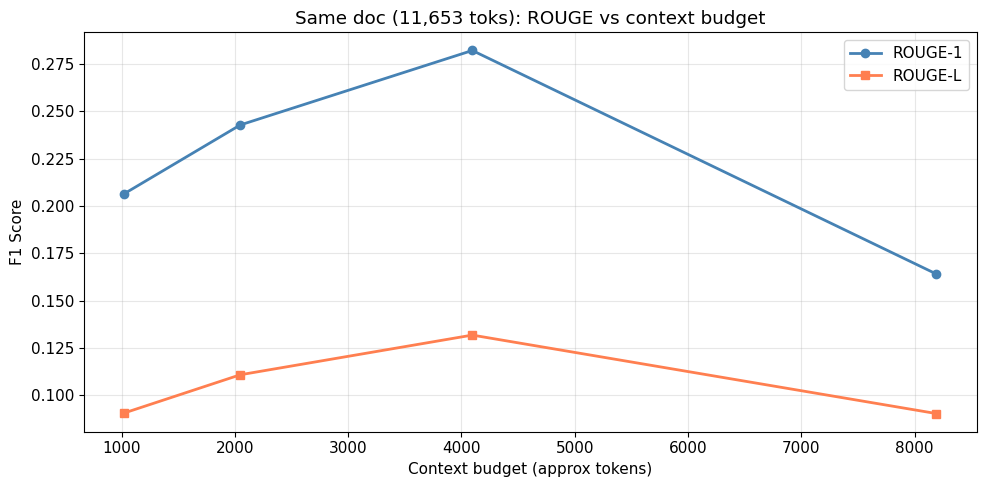

In [13]:
# Pick a long test doc
long_idx = np.where(test_doc_tokens > 10000)[0]
if len(long_idx) > 0:
    pick = long_idx[0]
    ex = test[int(pick)]
    full_doc_toks = test_doc_tokens[pick]
    full_doc_chars = len(ex["report"])
    ref = ex["summary"]
    
    print(f"Testing doc idx={pick}: {full_doc_toks:,} tokens ({full_doc_chars:,} chars)")
    print(f"Reference summary: {len(tokenizer.encode(ref, add_special_tokens=False)):,} tokens")
    print()
    
    context_results = []
    # Test at different char budgets (approx token equivalents)
    # ~3.2 chars/token → 3200 chars ≈ 1K tokens, etc.
    for budget_tokens, budget_chars in [(1024, 3200), (2048, 6400), (4096, 13000), (8192, 26000)]:
        if budget_chars > full_doc_chars * 1.1:
            continue
        print(f"  Context: ~{budget_tokens:,} tokens ({budget_chars:,} chars)...", end=" ", flush=True)
        
        summary, in_len, out_len, elapsed = generate_summary(
            ex["report"], max_doc_chars=budget_chars, max_new_tokens=600
        )
        scores = scorer.score(ref, summary)
        
        seen_pct = min(budget_chars, full_doc_chars) / full_doc_chars * 100
        
        context_results.append({
            "budget_tokens": budget_tokens,
            "budget_chars": budget_chars,
            "input_tokens": in_len,
            "seen_pct": seen_pct,
            "rouge1": scores["rouge1"].fmeasure,
            "rouge2": scores["rouge2"].fmeasure,
            "rougeL": scores["rougeL"].fmeasure,
            "summary": summary,
            "elapsed": elapsed,
        })
        print(f"in={in_len}, seen={seen_pct:.0f}%, R1={scores['rouge1'].fmeasure:.3f}, RL={scores['rougeL'].fmeasure:.3f} ({elapsed:.1f}s)")
    
    # Plot
    if context_results:
        fig, ax = plt.subplots(figsize=(10, 5))
        budgets = [r["budget_tokens"] for r in context_results]
        ax.plot(budgets, [r["rouge1"] for r in context_results], "o-", label="ROUGE-1", color="steelblue", lw=2)
        ax.plot(budgets, [r["rougeL"] for r in context_results], "s-", label="ROUGE-L", color="coral", lw=2)
        ax.set_xlabel("Context budget (approx tokens)")
        ax.set_ylabel("F1 Score")
        ax.set_title(f"Same doc ({full_doc_toks:,} toks): ROUGE vs context budget")
        ax.legend()
        plt.tight_layout(); plt.show()
else:
    print("No long docs found in test set for this analysis")

In [14]:
# Show the generated summaries at each context length
if 'context_results' in dir() and context_results:
    for cr in context_results:
        print(f"\n--- ~{cr['budget_tokens']:,} tokens ({cr['seen_pct']:.0f}% of doc) | R1={cr['rouge1']:.3f} | {cr['elapsed']:.1f}s ---")
        print(cr["summary"][:600])
        if len(cr["summary"]) > 600:
            print(f"  ...({len(cr['summary'])-600} chars more)")
    
    print(f"\n--- REFERENCE ---")
    print(ref[:600])


--- ~1,024 tokens (5% of doc) | R1=0.207 | 3.1s ---
The document outlines the process of technological innovation leading to commercialization, divided into three stages: inventing, transitioning to making, and selling. It emphasizes that innovation is inherently risky due to uncertain product value, with the Department of Commerce’s National Institute of Standards and Technology (NIST) and FDA/USDA playing critical roles in food safety. FDA ensures food safety for all except USDA-regulated items, while USDA oversees meat, poultry, eggs, and catfish. FDA conducts risk-based inspections, with high-risk facilities inspected every 3 years, and USD
  ...(249 chars more)

--- ~2,048 tokens (10% of doc) | R1=0.243 | 2.1s ---
The document outlines the process of technological innovation leading to commercialization, detailing the roles of the Department of Commerce’s National Institute of Standards and Technology (NIST) and FDA/USDA in food safety. Key points include:  
1. **Innovation-Comme

---
## 6. Summary: Base model diagnosis

In [15]:
print("=" * 70)
print("  QWEN3-0.6B BASE MODEL DIAGNOSIS")
print("  (Q4_K_M via llama.cpp)")
print("=" * 70)

if results:
    # Overall scores
    print(f"\nOverall ROUGE (N={len(results)}):")
    print(f"  ROUGE-1: {np.mean([r['rouge1'] for r in results]):.3f}")
    print(f"  ROUGE-2: {np.mean([r['rouge2'] for r in results]):.3f}")
    print(f"  ROUGE-L: {np.mean([r['rougeL'] for r in results]):.3f}")
    
    # Score by bucket
    print(f"\nROUGE-1 by length:")
    for label in dict.fromkeys(r["bucket"] for r in results):
        br = [r["rouge1"] for r in results if r["bucket"] == label]
        print(f"  {label:<22}: {np.mean(br):.3f} (N={len(br)})")
    
    # Performance
    total_in = sum(r["input_tokens"] for r in results)
    total_out = sum(r["output_tokens"] for r in results)
    total_time = sum(r["elapsed"] for r in results)
    print(f"\nPerformance (llama.cpp Q4_K_M):")
    print(f"  Total: {total_in:,} input + {total_out:,} output tokens in {total_time:.0f}s")
    print(f"  Avg throughput: {total_out/total_time:.1f} output tok/s")
    
    # Failure mode counts
    print(f"\nFailure modes observed:")
    n_short = sum(1 for r in results if len(r["generated"].split()) < 20)
    n_repetitive = 0
    for r in results:
        words = r["generated"].lower().split()
        if len(words) >= 4:
            fgs = [tuple(words[i:i+4]) for i in range(len(words)-3)]
            if len(set(fgs)) / len(fgs) < 0.7:
                n_repetitive += 1
    n_copy = sum(1 for r in results if ngram_overlap(r["doc_preview"][:300].lower(), r["generated"][:300].lower(), n=5) > 0.5)
    
    print(f"  Too short (<20 words): {n_short}/{len(results)}")
    print(f"  Repetitive:            {n_repetitive}/{len(results)}")
    print(f"  Copies doc start:      {n_copy}/{len(results)}")

    # Positional bias
    if positional_data:
        print(f"\nPositional bias (generated vs reference):")
        gen_t = np.array(gen_firsts) + np.array(gen_middles) + np.array(gen_lasts)
        ref_t = np.array(ref_firsts) + np.array(ref_middles) + np.array(ref_lasts)
        sg = gen_t > 0
        sr = ref_t > 0
        if sg.any() and sr.any():
            gf = np.array(gen_firsts)[sg].sum()/gen_t[sg].sum()*100
            gm = np.array(gen_middles)[sg].sum()/gen_t[sg].sum()*100
            gl = np.array(gen_lasts)[sg].sum()/gen_t[sg].sum()*100
            rf = np.array(ref_firsts)[sr].sum()/ref_t[sr].sum()*100
            rm = np.array(ref_middles)[sr].sum()/ref_t[sr].sum()*100
            rl_pos = np.array(ref_lasts)[sr].sum()/ref_t[sr].sum()*100
            print(f"  Generated: first={gf:.0f}% / middle={gm:.0f}% / last={gl:.0f}%")
            print(f"  Reference: first={rf:.0f}% / middle={rm:.0f}% / last={rl_pos:.0f}%")
            bias = gf - rf
            if bias > 10:
                print(f"  -> Model OVER-ATTENDS to beginning (+{bias:.0f}%) — primacy bias detected")
            elif abs(bias) <= 10:
                print(f"  -> Positional coverage is roughly balanced")
            else:
                print(f"  -> Model under-attends beginning ({bias:.0f}%)")

print(f"\n{'='*70}")
print("  These findings inform what SFT needs to fix.")
print(f"{'='*70}")

  QWEN3-0.6B BASE MODEL DIAGNOSIS
  (Q4_K_M via llama.cpp)

Overall ROUGE (N=15):
  ROUGE-1: 0.262
  ROUGE-2: 0.086
  ROUGE-L: 0.149

ROUGE-1 by length:
  short (<2K)           : 0.188 (N=3)
  medium (2-4K)         : 0.265 (N=3)
  long (4-8K)           : 0.347 (N=3)
  very long (8-16K)     : 0.268 (N=3)
  extreme (>16K)        : 0.242 (N=3)

Performance (llama.cpp Q4_K_M):
  Total: 60,074 input + 7,463 output tokens in 68s
  Avg throughput: 110.4 output tok/s

Failure modes observed:
  Too short (<20 words): 1/15
  Repetitive:            0/15
  Copies doc start:      0/15

Positional bias (generated vs reference):
  Generated: first=58% / middle=19% / last=23%
  Reference: first=50% / middle=29% / last=21%
  -> Positional coverage is roughly balanced

  These findings inform what SFT needs to fix.
